In [145]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.style as style
style.use('~/styles/clarke-default.mplstyle')
import tensorflow as tf
from tensorflow import keras
from scipy.interpolate import griddata
from scipy.optimize import curve_fit
import yaml

In [340]:
pmts = False
sensors = 'PMTs' if pmts else 'SiPMs'
ind_sipms = True
save_figures = True
pmt_qe = 1.
ph_per_elec = 50.
s2_cut = 15.
pmt_diam = 51
acceptance = 10000
n_photons = 1e4
n_events = 1e4
file_prefix = "chroma-lxe/sim_infinite_{:.0f}mm_diam_{:.0f}deg_acceptance_{:.0e}_photons_{:.0e}_events"\
              .format(pmt_diam, acceptance, n_photons, n_events)

In [341]:
mc_truth_pos = []
detected = []
pte = []

with h5py.File(file_prefix + '_ss.h5', 'r') as f:
    print(f.keys())
    print(np.mean(f['pte']))
    for key in f.keys():
        if '_detected' in key:
            detected.append(f[key][()])
        elif 'posX' in key:
            mc_truth_pos.append(f[key][()])
        elif 'posY' in key:
            mc_truth_pos.append(f[key][()])
        elif 'posZ' in key:
            mc_truth_pos.append(f[key][()])
        elif key=='pte':
            pte.append(f[key][()])

ss_mc_truth_pos = np.array(mc_truth_pos).swapaxes(0, 1)
# ss_n_detected = np.random.binomial(np.array(detected).swapaxes(0, 1).astype(int), pmt_qe)
ss_n_detected = np.array(detected).swapaxes(0, 1).astype(int)
ss_pte = np.array(pte)[0]

<KeysViewHDF5 ['ch000_detected', 'ch000_pte', 'ch001_detected', 'ch001_pte', 'ch002_detected', 'ch002_pte', 'ch003_detected', 'ch003_pte', 'ch004_detected', 'ch004_pte', 'ch005_detected', 'ch005_pte', 'ch006_detected', 'ch006_pte', 'ch007_detected', 'ch007_pte', 'ch008_detected', 'ch008_pte', 'ch009_detected', 'ch009_pte', 'ch010_detected', 'ch010_pte', 'ch011_detected', 'ch011_pte', 'ch012_detected', 'ch012_pte', 'ch013_detected', 'ch013_pte', 'ch014_detected', 'ch014_pte', 'ch015_detected', 'ch015_pte', 'ch016_detected', 'ch016_pte', 'ch017_detected', 'ch017_pte', 'ch018_detected', 'ch018_pte', 'ch019_detected', 'ch019_pte', 'ch020_detected', 'ch020_pte', 'ch021_detected', 'ch021_pte', 'ch022_detected', 'ch022_pte', 'ch023_detected', 'ch023_pte', 'ch024_detected', 'ch024_pte', 'ch025_detected', 'ch025_pte', 'ch026_detected', 'ch026_pte', 'ch027_detected', 'ch027_pte', 'ch028_detected', 'ch028_pte', 'ch029_detected', 'ch029_pte', 'ch030_detected', 'ch030_pte', 'ch031_detected', 'ch031

In [342]:
# with open('/home/clarke/stl/infinite_tpc/pmt_center_inds.yaml', 'r') as f:
#     center_inds = yaml.safe_load(f)
#     center_ind = center_inds['{:.0f}mm'.format(pmt_diam)]

In [343]:
# rad_pos = np.sqrt(np.sum((ss_mc_truth_pos[:,:2] - np.array((0, pmt_diam/2.))[None,:])**2, axis=1))
rad_pos = np.sqrt(np.sum(ss_mc_truth_pos[:,:2]**2, axis=1))
center_mask = rad_pos < pmt_diam/2.
counts_masked = np.copy(ss_n_detected)
counts_masked[~center_mask] = 0
# center_ind = np.argmax(np.sum(ss_n_detected, axis=0))
counts_masked.shape

(10000, 199)

In [344]:
center_ind = np.argmax(np.sum(ss_n_detected[center_mask,:], axis=0))

In [345]:
center_ind

198

In [346]:
np.mean(ss_mc_truth_pos[:,2])

229.94998

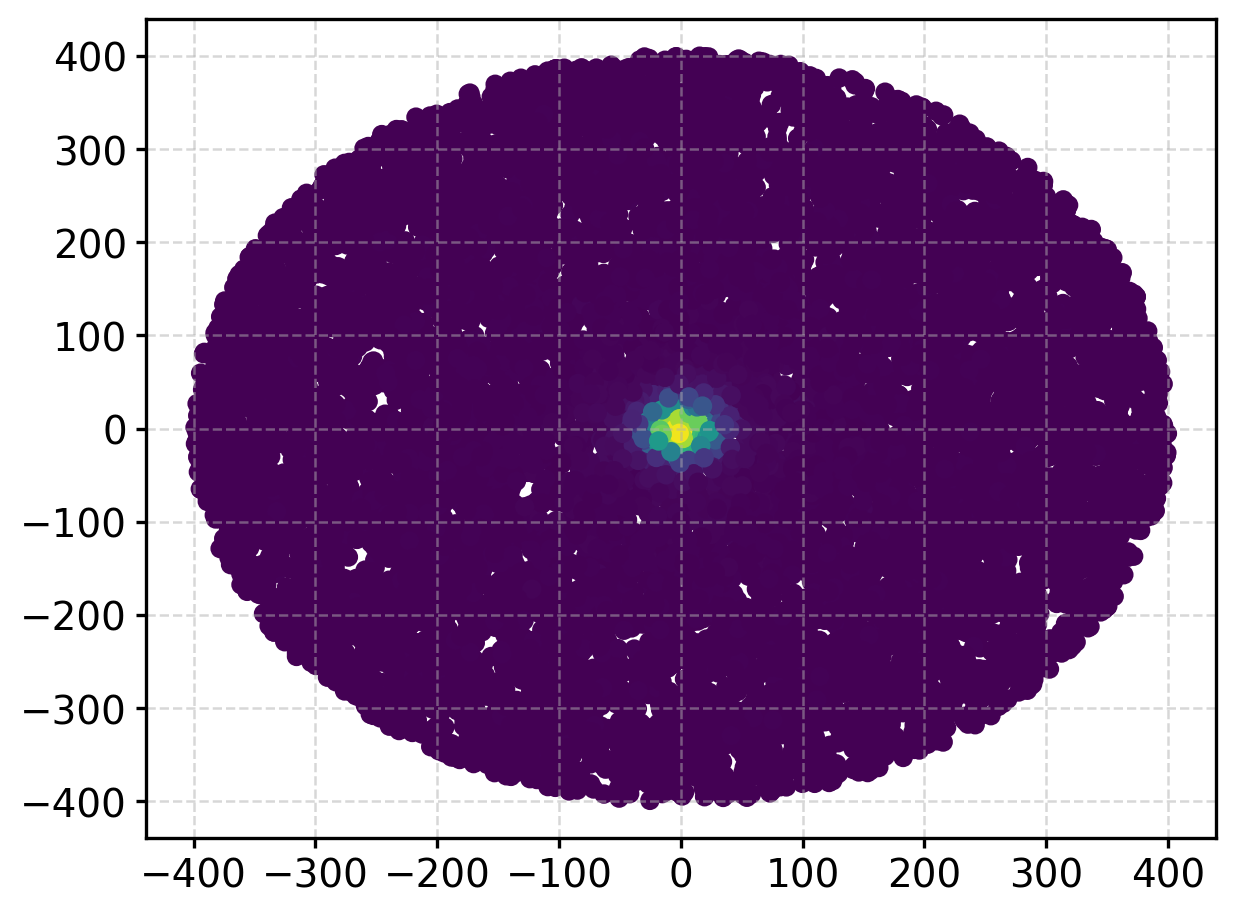

In [347]:
plt.figure()
plt.scatter(ss_mc_truth_pos[:,0], ss_mc_truth_pos[:,1], c=ss_n_detected[:, center_ind])
plt.grid()

In [348]:
np.sum(det_center_pmt)

52093

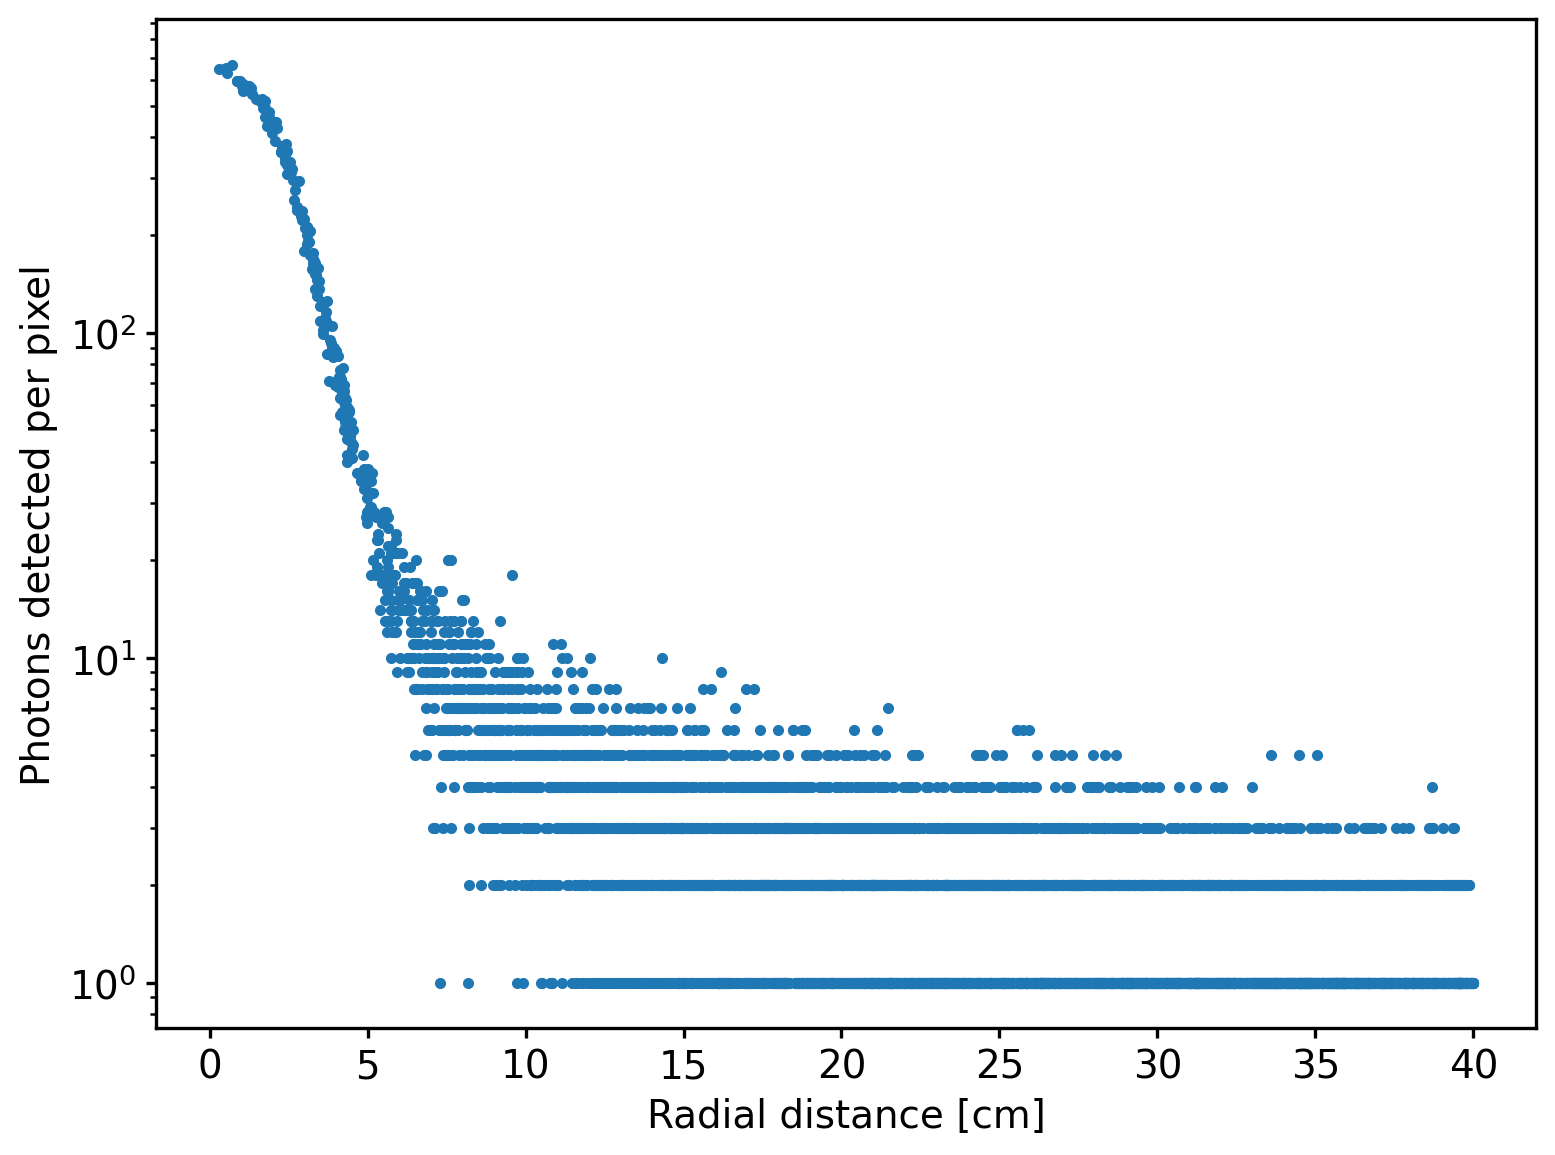

In [349]:
det_center_pmt = ss_n_detected[:, center_ind]

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rad_pos/10., det_center_pmt, ls='none', marker='.')
ax.set_xlabel('Radial distance [cm]')
ax.set_ylabel('Photons detected per pixel')
ax.set_yscale('log')

[6.23426352e+02 4.51318514e+00 2.60848446e-01 4.84604620e+00
 3.18398327e+00]


/tmp/ipykernel_1426/1783827754.py:3: RuntimeWarning: divide by zero encountered in power
  return A*np.exp(-a*rho/(1 + rho**(1 - alpha)) - b/(1 + rho**(-alpha)))


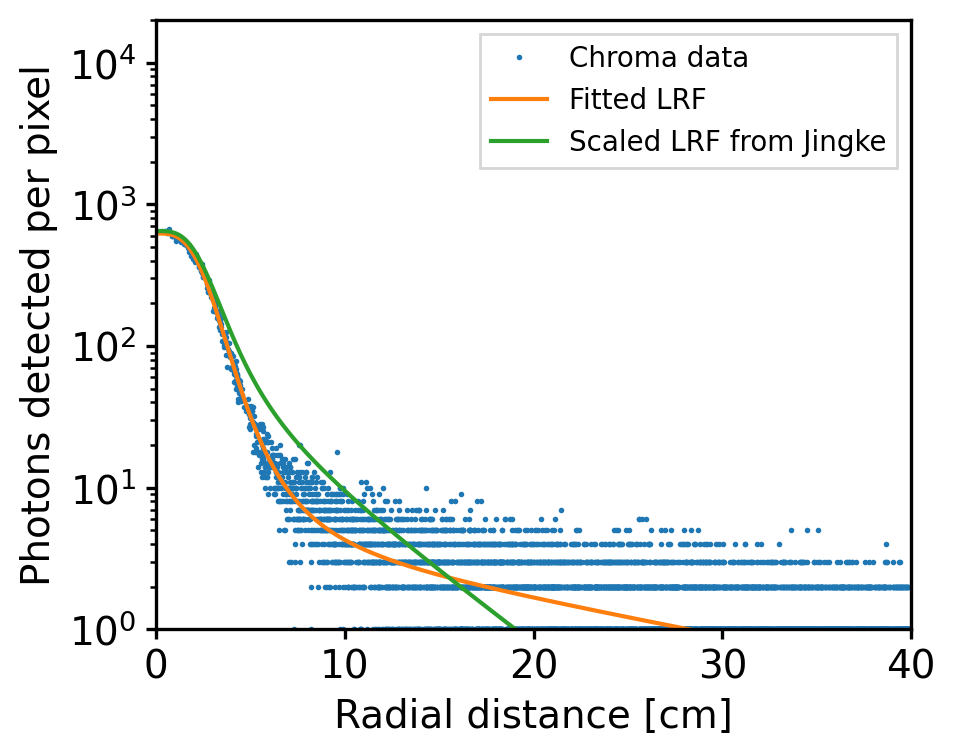

In [350]:
def lrf(r, A, r0, a, b, alpha):
    rho = r/r0
    return A*np.exp(-a*rho/(1 + rho**(1 - alpha)) - b/(1 + rho**(-alpha)))

p, c = curve_fit(lrf, rad_pos/10., det_center_pmt, p0=[2000, 4., 0.9, 2., 3.])

print(p)

plot_rvals = np.linspace(0, 40, 1000)

pvals = [2.6e3*0.249655, 3.85849, 0.875124, 2.26991, 3.32806]
# pvals = [2497., 3.858, -0.8751, -2.27, -3.328]

fig, ax = plt.subplots(figsize=(5, 4))
ax.plot(rad_pos/10., det_center_pmt, ls='none', marker='.', ms=2, label='Chroma data')
ax.plot(plot_rvals, lrf(plot_rvals, *p), label='Fitted LRF')
ax.plot(plot_rvals, lrf(plot_rvals, *pvals), label='Scaled LRF from Jingke')
ax.set_xlabel('Radial distance [cm]')
ax.set_ylabel('Photons detected per pixel')
ax.set_yscale('log')
ax.set_ylim([1e0, 2e4])
ax.set_xlim([0, 40])
ax.legend(loc='upper right')
# fig.savefig('/home/clarke/figures/LRF_51mm_pmts_85deg_acceptance_1e5_photons_1e4_events.png')

In [323]:
p[0]/np.sum(det_center_pmt)

0.012906794502162084

In [502]:
# Assume mc_truth_pos is (2, N) and ss_n_detected is (N, num_sipms)
num_sipms = ss_n_detected.shape[1]

# Compute weighted average x and y for each SiPM
weighted_x = np.sum(ss_n_detected * ss_mc_truth_pos[:, 0, np.newaxis], axis=0) / np.sum(ss_n_detected, axis=0)
weighted_y = np.sum(ss_n_detected * ss_mc_truth_pos[:, 1, np.newaxis], axis=0) / np.sum(ss_n_detected, axis=0)

# Stack into (num_sipms, 2) array
sipm_positions = np.stack([weighted_x, weighted_y], axis=1)

# Sort SiPMs into grid layout
# This part assumes the grid is regular and oriented such that increasing y is "up"
# First sort by y (descending), then x (ascending) within rows

# Estimate number of rows and columns assuming square grid
side = int(np.sqrt(num_sipms))
assert side * side == num_sipms, "SiPM array must be square"

# Sort by y decreasing (top to bottom)
row_indices = np.argsort(-sipm_positions[:,1])
rows = np.array_split(row_indices, side)

# Within each row, sort by x increasing (left to right)
ind_mapping = []
for row in rows:
    sorted_row = row[np.argsort(sipm_positions[row, 0])]
    ind_mapping.extend(sorted_row.tolist())

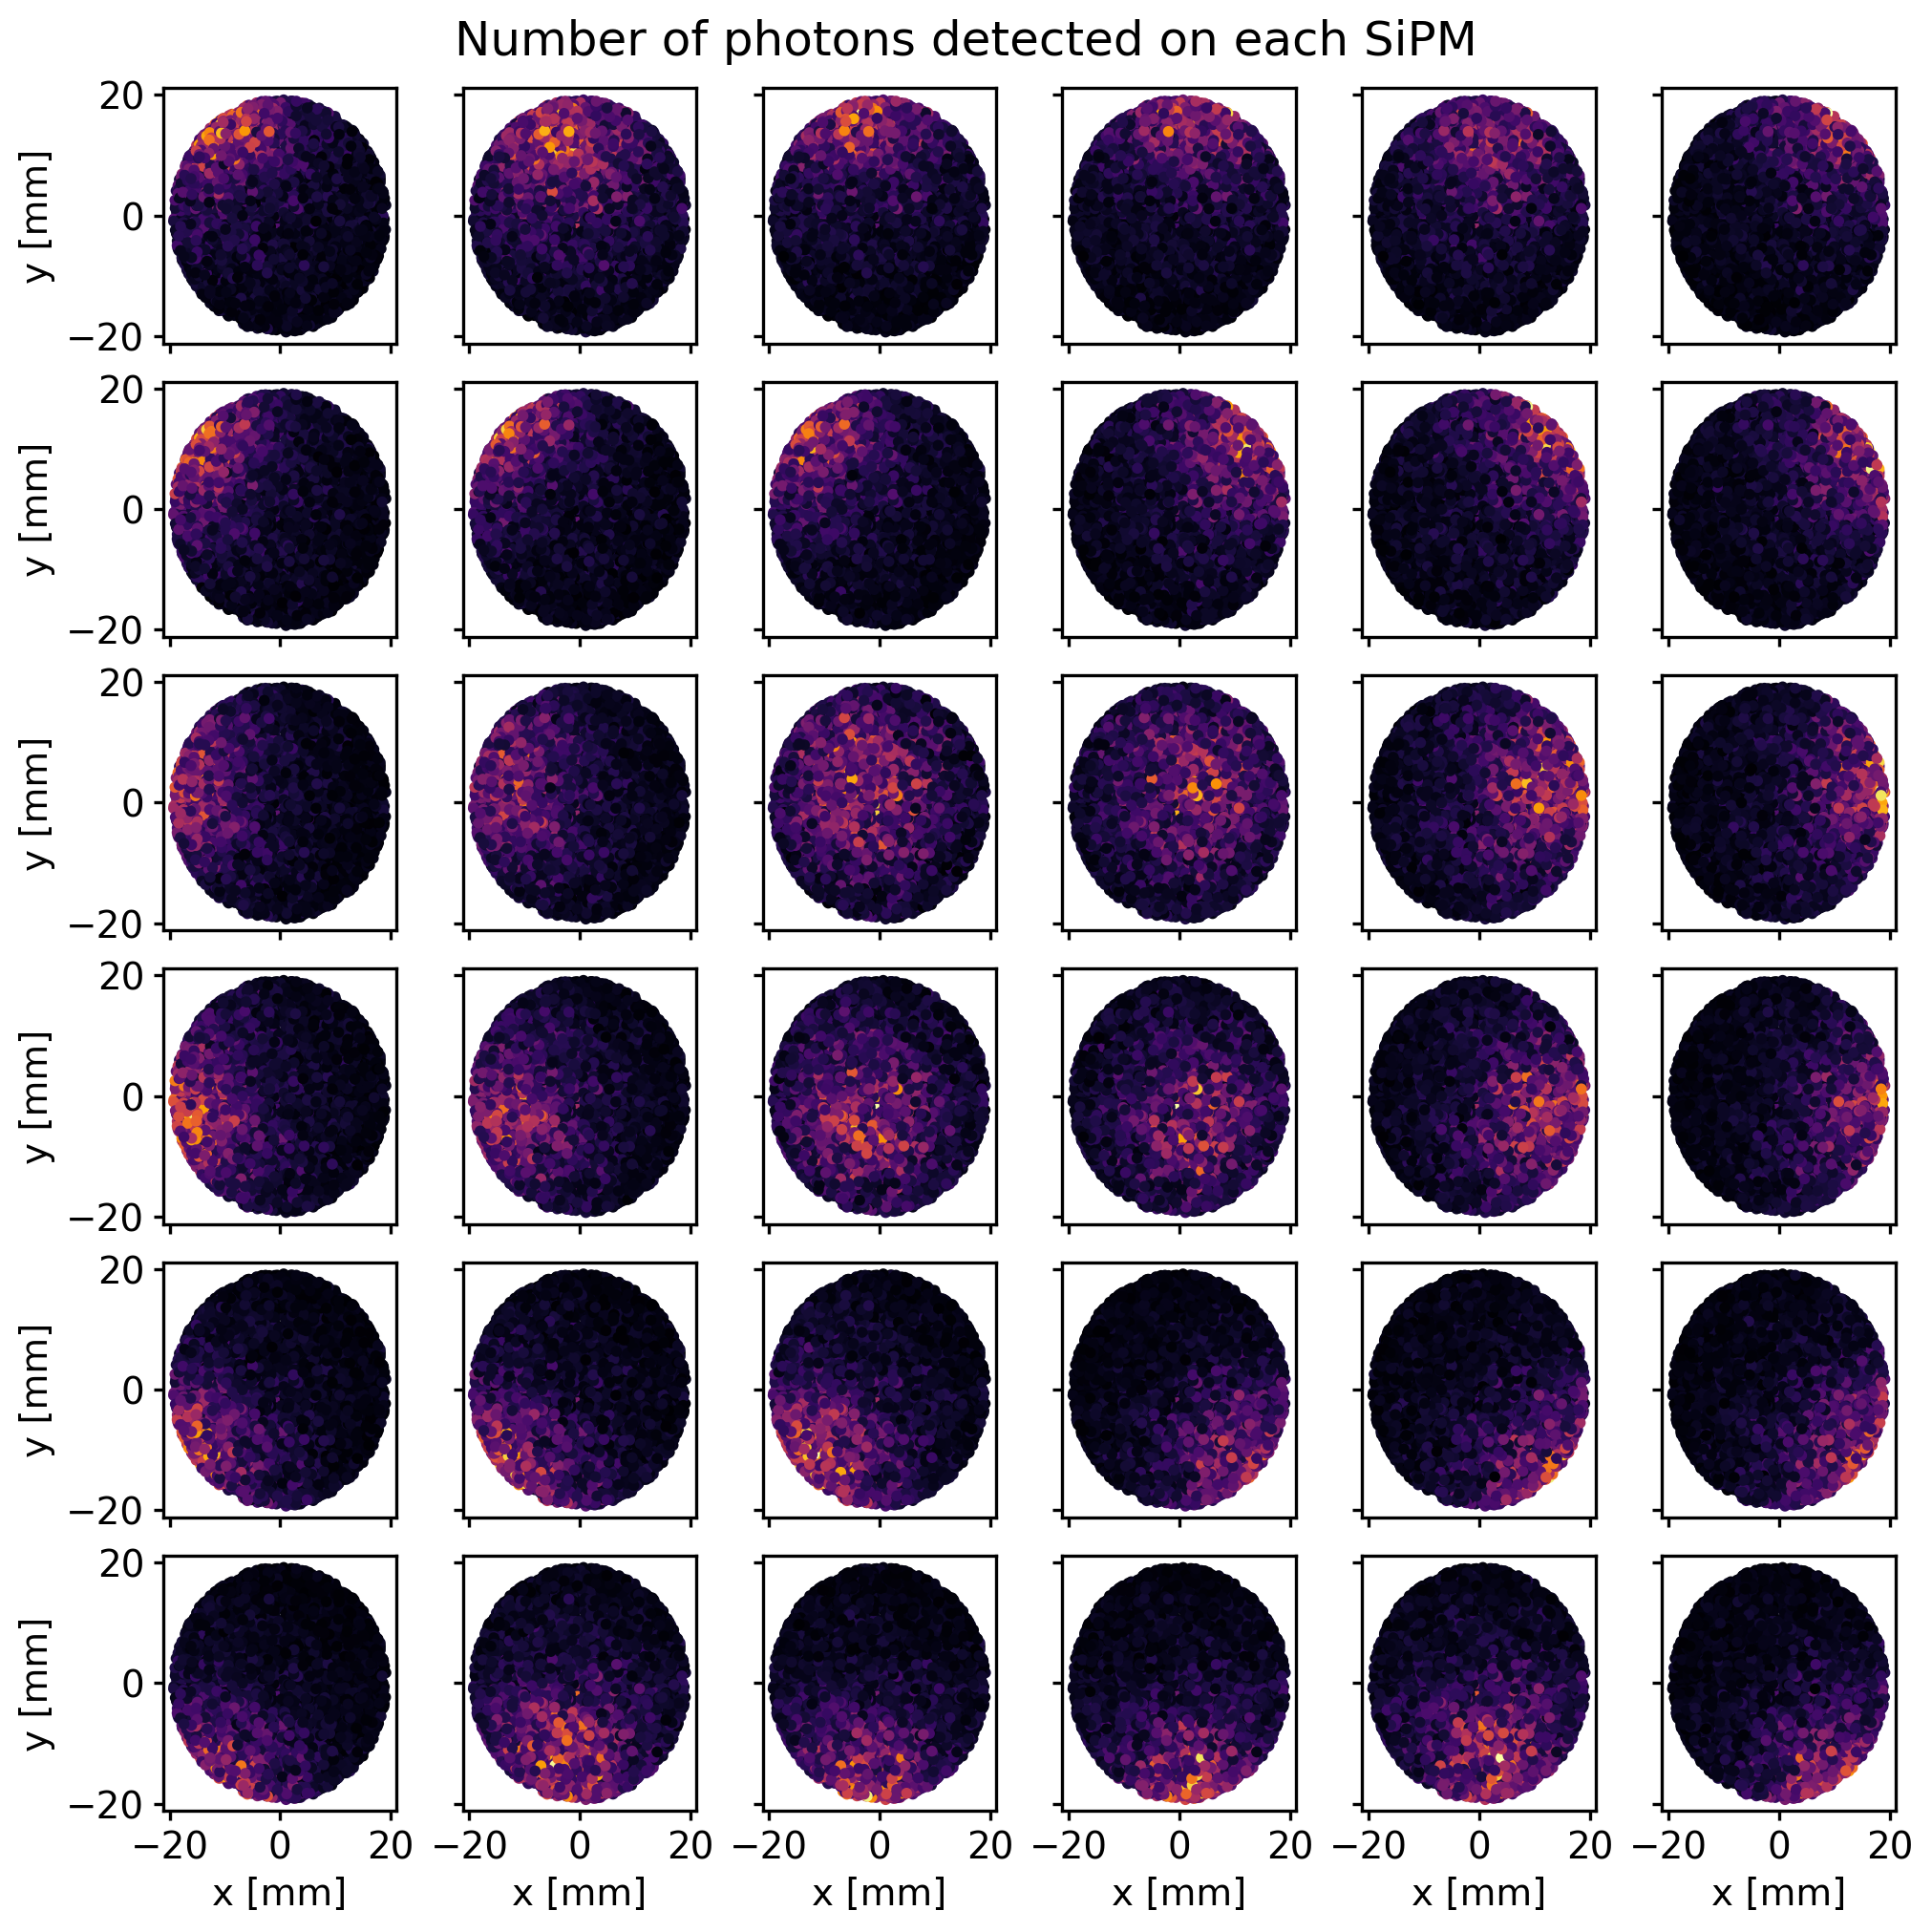

In [478]:
num_cols = 2 if pmts else [3, 6][int(ind_sipms)]

fig, ax = plt.subplots(num_cols, num_cols, figsize=(10, 10), sharex='col', sharey='row', layout='constrained')
mapping = [2,3,1,0] if pmts else [[2,1,0,5,4,3,8,7,6], ind_mapping][int(ind_sipms)]

for i in range(num_cols):
    for j in range(num_cols):
        ax[i,j].scatter(ss_mc_truth_pos[:, 0], ss_mc_truth_pos[:, 1], \
                        c=ss_n_detected[:,mapping[num_cols*i + j]], \
                        cmap='inferno', s=10)
        if i == num_cols - 1:
            ax[i,j].set_xlabel('x [mm]')
        if j == 0:
            ax[i,j].set_ylabel('y [mm]')

fig.suptitle('Number of photons detected on each ' + sensors[:-1])
if save_figures:
    fig.savefig('/home/clarke/figures/num_photons_by_' + sensors[:-1] + '_' + fig_string + '.png')

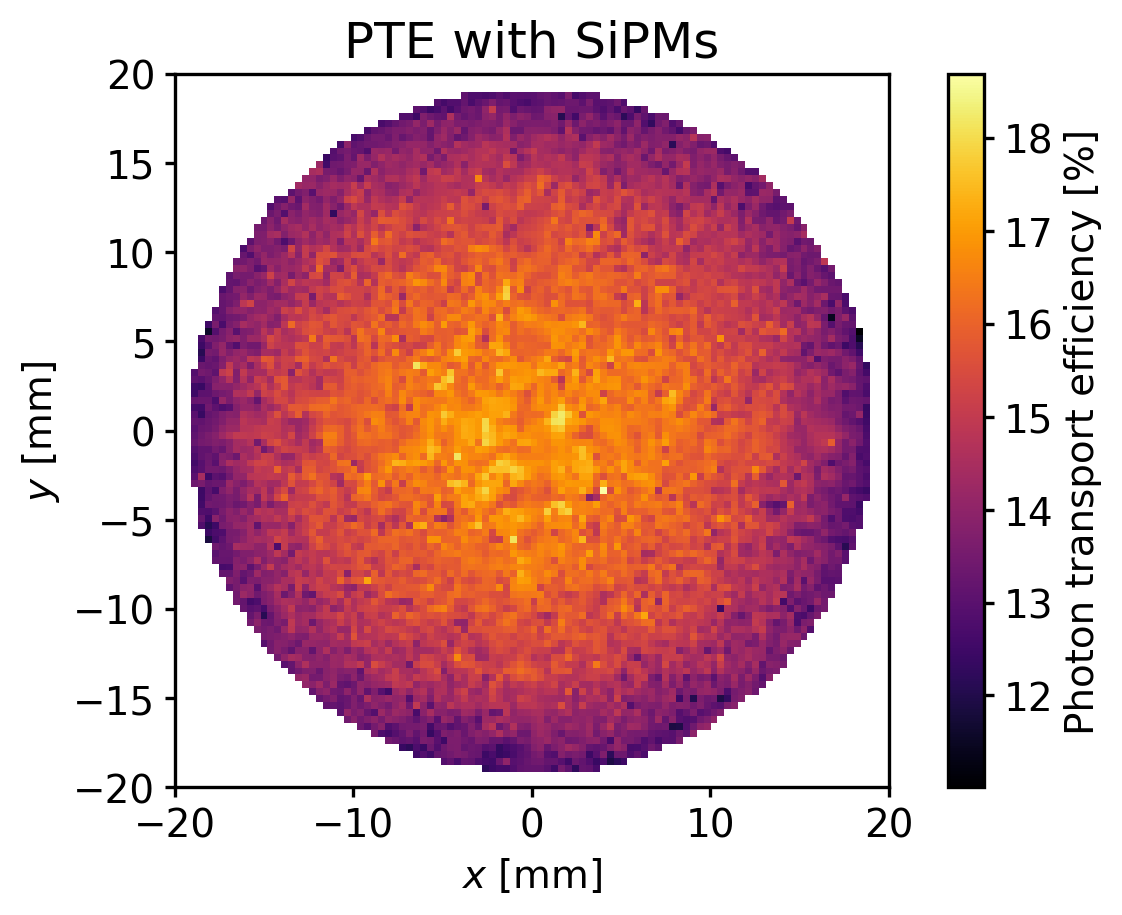

In [503]:
xi = np.linspace(np.amin(ss_mc_truth_pos[:,0]), np.amax(ss_mc_truth_pos[:,0]), 100)
yi = np.linspace(np.amin(ss_mc_truth_pos[:,1]), np.amax(ss_mc_truth_pos[:,1]), 100)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((ss_mc_truth_pos[:,0], ss_mc_truth_pos[:,1]), 100*ss_pte, (xi, yi), method='linear')

fig, ax = plt.subplots()
mesh = ax.pcolormesh(xi, yi, zi, cmap='inferno')
ax.set_aspect('equal')
ax.set_xlim([-20, 20])
ax.set_ylim([-20, 20])
ax.set_xlabel('$x$ [mm]')
ax.set_ylabel('$y$ [mm]')
cbar = fig.colorbar(mesh)
cbar.set_label('Photon transport efficiency [%]')
ax.set_title('PTE with ' + sensors)
if save_figures:
    fig.savefig('/home/clarke/figures/pte_map_' + sensors[:-1] + '_' + fig_string + '.png')

In [250]:
r = 25.
s = 20.

angle = np.arctan(2*r/s)
2*np.cos(angle)*2*angle/4./np.pi

0.14071289254033537

In [252]:
def solid_angle_frac(z, a):
    return 0.5*(1. - z/np.sqrt(z**2 + a**2))

solid_angle_frac(20., 25.)

0.18765247622278786

In [505]:
mc_truth_pos = []
mc_truth_pos_2 = []
detected = []

with h5py.File(file_prefix + '_ms.h5', 'r') as f:
    print(f.keys())
    for key in f.keys():
        if '_detected' in key:
            detected.append(f[key][()])
        elif key=='posX':
            mc_truth_pos.append(f[key][()])
        elif key=='posY':
            mc_truth_pos.append(f[key][()])
        elif key=='posZ':
            mc_truth_pos.append(f[key][()])
        elif key=='posX_2':
            mc_truth_pos_2.append(f[key][()])
        elif key=='posY_2':
            mc_truth_pos_2.append(f[key][()])
        elif key=='posZ_2':
            mc_truth_pos_2.append(f[key][()])

ms_mc_truth_pos = np.array(mc_truth_pos).swapaxes(0, 1)
ms_mc_truth_pos_2 = np.array(mc_truth_pos_2).swapaxes(0, 1)
ms_n_detected = np.random.binomial(np.array(detected).swapaxes(0, 1).astype(int), pmt_qe)
# ms_n_detected = np.array(detected).swapaxes(0, 1).astype(int)

def spatial_sep(pos, pos2):
    """Get the distance between two points in a MS event
    """
    return np.sqrt(np.sum(((pos - pos2)**2)[:,:2], axis=1))

seps = spatial_sep(ms_mc_truth_pos, ms_mc_truth_pos_2)

<KeysViewHDF5 ['ch00_detected', 'ch00_pte', 'ch01_detected', 'ch01_pte', 'ch02_detected', 'ch02_pte', 'ch03_detected', 'ch03_pte', 'ch04_detected', 'ch04_pte', 'ch05_detected', 'ch05_pte', 'ch06_detected', 'ch06_pte', 'ch07_detected', 'ch07_pte', 'ch08_detected', 'ch08_pte', 'ch09_detected', 'ch09_pte', 'ch10_detected', 'ch10_pte', 'ch11_detected', 'ch11_pte', 'ch12_detected', 'ch12_pte', 'ch13_detected', 'ch13_pte', 'ch14_detected', 'ch14_pte', 'ch15_detected', 'ch15_pte', 'ch16_detected', 'ch16_pte', 'ch17_detected', 'ch17_pte', 'ch18_detected', 'ch18_pte', 'ch19_detected', 'ch19_pte', 'ch20_detected', 'ch20_pte', 'ch21_detected', 'ch21_pte', 'ch22_detected', 'ch22_pte', 'ch23_detected', 'ch23_pte', 'ch24_detected', 'ch24_pte', 'ch25_detected', 'ch25_pte', 'ch26_detected', 'ch26_pte', 'ch27_detected', 'ch27_pte', 'ch28_detected', 'ch28_pte', 'ch29_detected', 'ch29_pte', 'ch30_detected', 'ch30_pte', 'ch31_detected', 'ch31_pte', 'ch32_detected', 'ch32_pte', 'ch33_detected', 'ch33_pte',

In [506]:
mask = np.sum(ms_n_detected, axis=1)/np.mean(ss_pte)/pmt_qe/ph_per_elec > s2_cut
ms_n_detected = ms_n_detected[mask, :]
ms_mc_truth_pos = ms_mc_truth_pos[mask, :]
ms_mc_truth_pos_2 = ms_mc_truth_pos_2[mask, :]

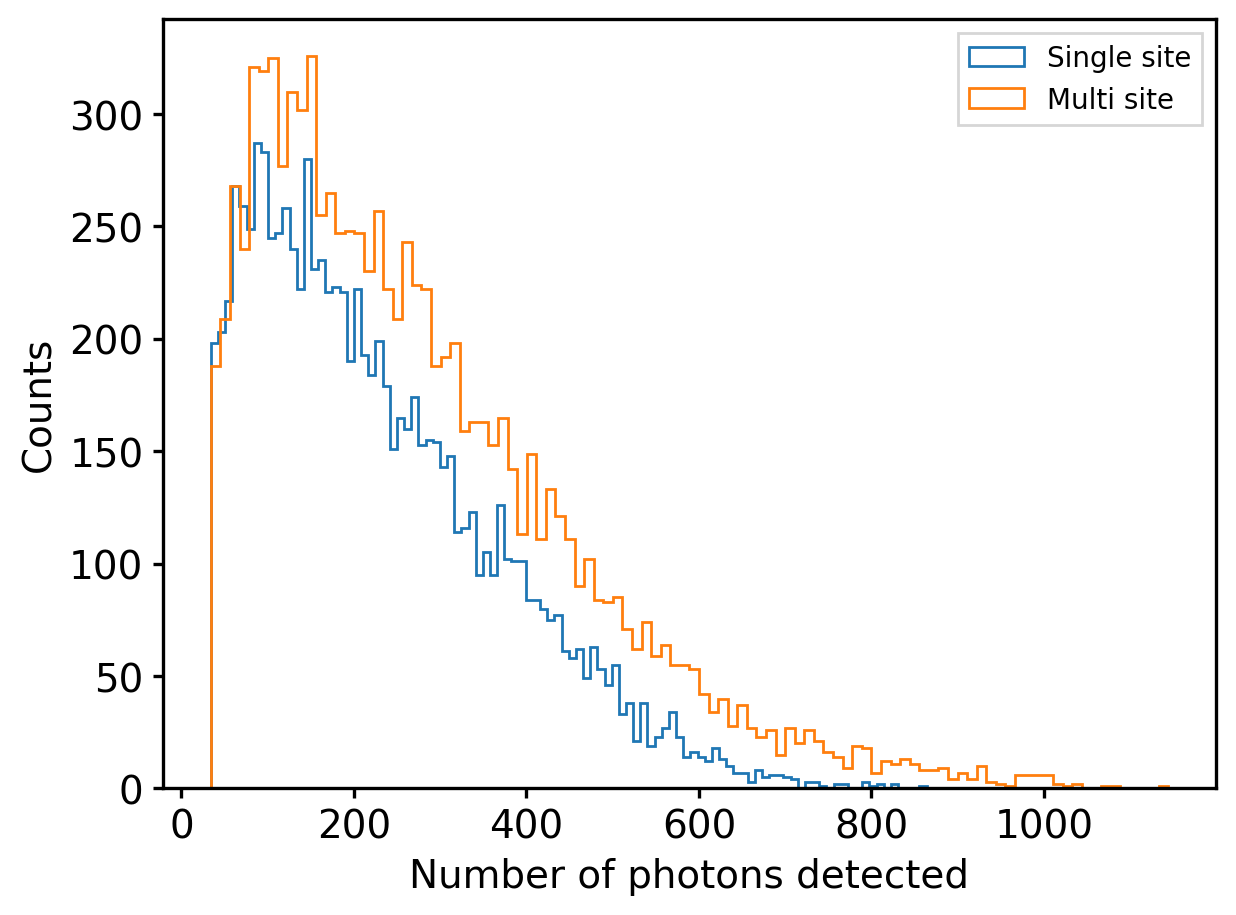

In [507]:
bins = np.linspace(1750, 2750, 100)
fig, ax = plt.subplots()
ax.hist(np.sum(ss_n_detected, axis=1), histtype='step', bins=100, label='Single site')
ax.hist(np.sum(ms_n_detected, axis=1), histtype='step', bins=100, label='Multi site')
ax.set_xlabel('Number of photons detected')
ax.set_ylabel('Counts')
ax.legend()

In [555]:
n_detected = np.concatenate((ss_n_detected, ms_n_detected), axis=0)
# remove absolute energy scale and only use relative counts between sensors
n_detected = n_detected[np.sum(n_detected, axis=1) > 0]
n_detected = n_detected/np.sum(n_detected, axis=1, keepdims=True)
ss_truth = np.ones(ss_n_detected.shape[0])
ms_truth = np.zeros(ms_n_detected.shape[0])
truth = np.concatenate((ss_truth, ms_truth), axis=0)
seps_both = np.concatenate((np.zeros(len(ss_n_detected)), seps))

# Generate a random permutation
permutation = np.random.permutation(n_detected.shape[0])

# Apply the permutation to both arrays
n_detected_shuffled = n_detected[permutation]#.reshape(-1, 6, 6)
truth_shuffled = truth[permutation]#.reshape(-1, 6, 6)
seps_shuffled = seps_both[permutation]#.reshape(-1, 6, 6)

In [556]:
cnn = True

if cnn:
    n_detected_shuffled = n_detected_shuffled[:, np.array(ind_mapping)].reshape(-1, 6, 6)

In [567]:
from tensorflow.keras import layers, models, initializers

def build_cnn_model():
    he_init = initializers.HeNormal()  # works well with ReLU and LeakyReLU

    model = models.Sequential([
        layers.Input(shape=(6, 6, 1)),

        layers.Conv2D(16, (2, 2), padding='same', kernel_initializer=he_init),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(32, (4, 4), padding='same', kernel_initializer=he_init),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(64, kernel_initializer=he_init),
        layers.LeakyReLU(alpha=0.1),

        layers.Dense(32, kernel_initializer=he_init),
        layers.LeakyReLU(alpha=0.1),

        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

    return model

In [568]:
if pmts:
    # Define the model
    model = keras.Sequential([
        keras.layers.Dense(64, activation='relu', input_shape=(4,)),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    # Compile the model
    model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])

    # Print model summary
    model.summary()
else:
    # Define the model
    model = keras.Sequential([
        keras.layers.Dense(512, activation='relu', input_shape=([9, 36][int(ind_sipms)],)),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(16, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')
    ])

    # Compile the model
    model.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics=['accuracy'])
    if cnn:
        model = build_cnn_model()

    # Print model summary
    model.summary()

Model: "sequential_78"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_68 (Conv2D)          (None, 6, 6, 16)          80        
                                                                 
 leaky_re_lu_84 (LeakyReLU)  (None, 6, 6, 16)          0         
                                                                 
 max_pooling2d_68 (MaxPooli  (None, 3, 3, 16)          0         
 ng2D)                                                           
                                                                 
 conv2d_69 (Conv2D)          (None, 3, 3, 32)          8224      
                                                                 
 leaky_re_lu_85 (LeakyReLU)  (None, 3, 3, 32)          0         
                                                                 
 max_pooling2d_69 (MaxPooli  (None, 1, 1, 32)          0         
 ng2D)                                               

Epoch 1/50
602/602 [==============================] - 2s 2ms/step - loss: 0.6925 - accuracy: 0.5174 - val_loss: 0.6892 - val_accuracy: 0.5506 - lr: 0.0010
Epoch 2/50
602/602 [==============================] - 1s 2ms/step - loss: 0.6887 - accuracy: 0.5374 - val_loss: 0.6860 - val_accuracy: 0.5473 - lr: 0.0010
Epoch 3/50
602/602 [==============================] - 1s 2ms/step - loss: 0.6855 - accuracy: 0.5534 - val_loss: 0.6870 - val_accuracy: 0.5465 - lr: 0.0010
Epoch 4/50
602/602 [==============================] - 1s 2ms/step - loss: 0.6836 - accuracy: 0.5614 - val_loss: 0.6830 - val_accuracy: 0.5561 - lr: 0.0010
Epoch 5/50
602/602 [==============================] - 1s 2ms/step - loss: 0.6811 - accuracy: 0.5649 - val_loss: 0.6854 - val_accuracy: 0.5480 - lr: 0.0010
Epoch 6/50
602/602 [==============================] - 1s 2ms/step - loss: 0.6813 - accuracy: 0.5654 - val_loss: 0.6857 - val_accuracy: 0.5509 - lr: 0.0010
Epoch 7/50
602/602 [==============================] - 1s 2ms/step - lo

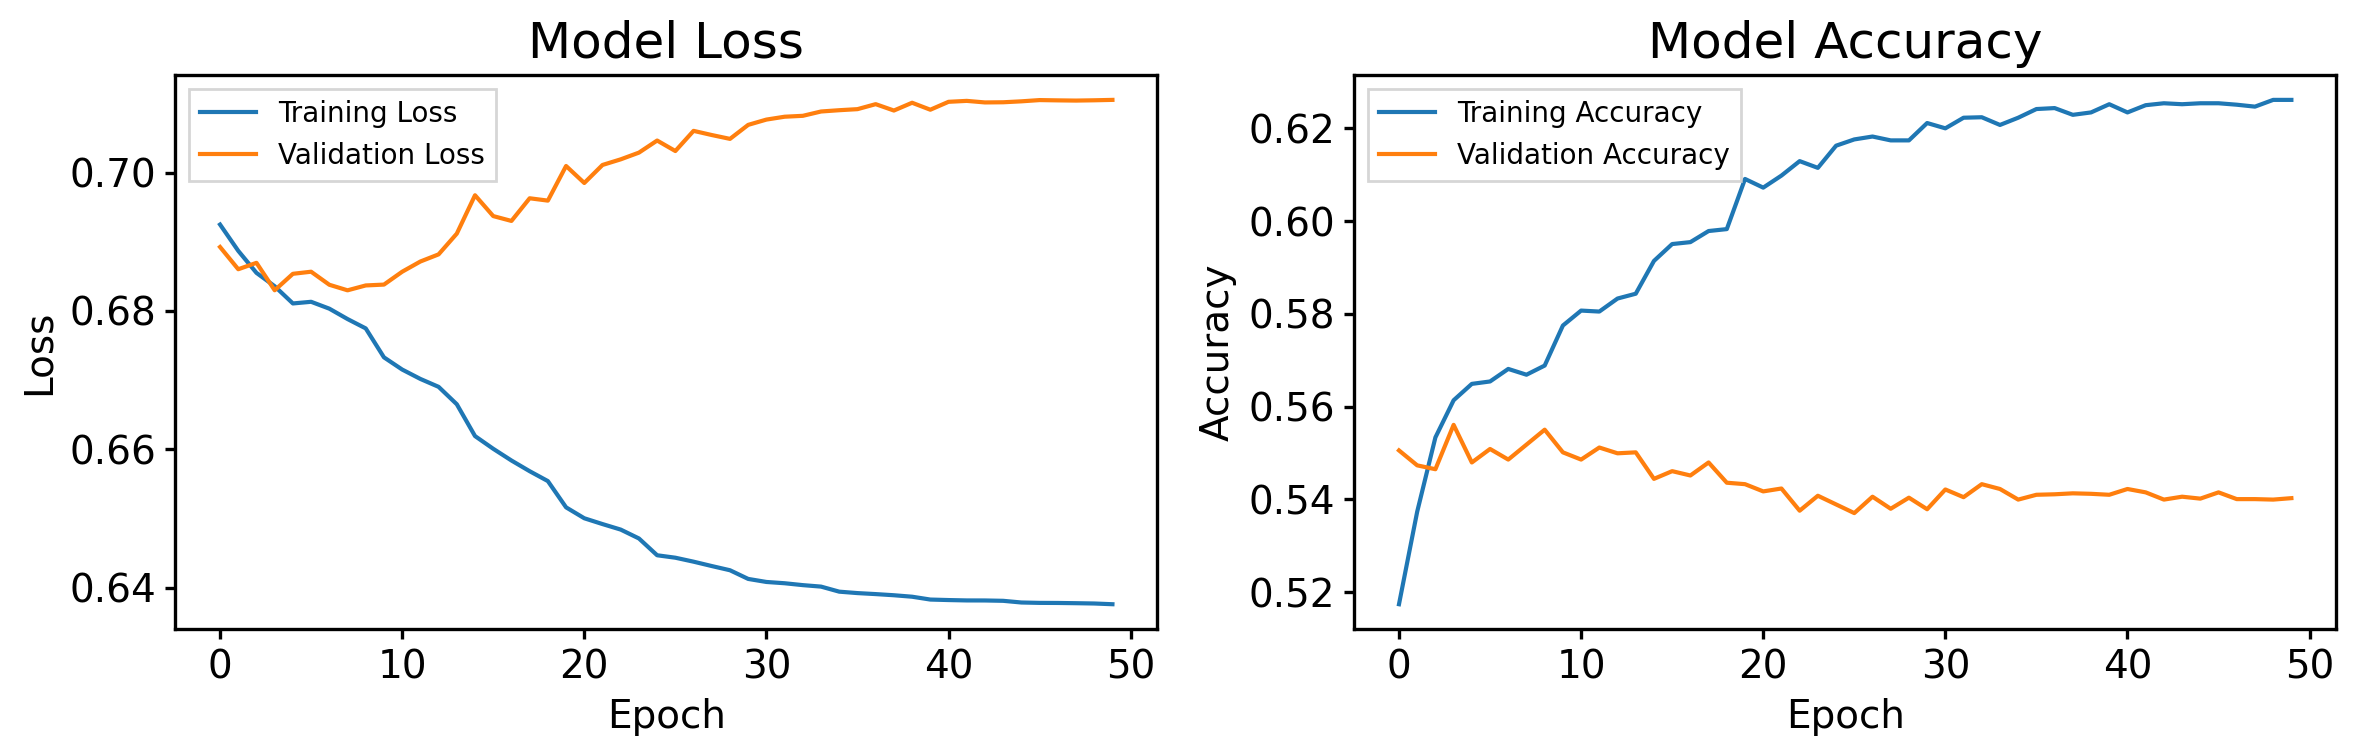

In [569]:
# Split the data into training and validation sets
split_index = len(n_detected_shuffled) // 2
X_train, X_val = n_detected_shuffled[:split_index], n_detected_shuffled[split_index:]
y_train, y_val = truth_shuffled[:split_index], truth_shuffled[split_index:]
seps_train, seps_val = seps_shuffled[:split_index], seps_shuffled[split_index:]

lr_schedule = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1,
    min_lr=1e-6)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1,
    callbacks=[lr_schedule]
)

# Evaluate the model on the validation set
val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")

# Plot training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

if save_figures:
    plt.savefig('/home/clarke/figures/training_individual' + sensors + '_' + fig_string + '.png')

plt.tight_layout()
plt.show()

Youden optimal cut keeps 54.8% of signal events and removes 53.7% of background events.


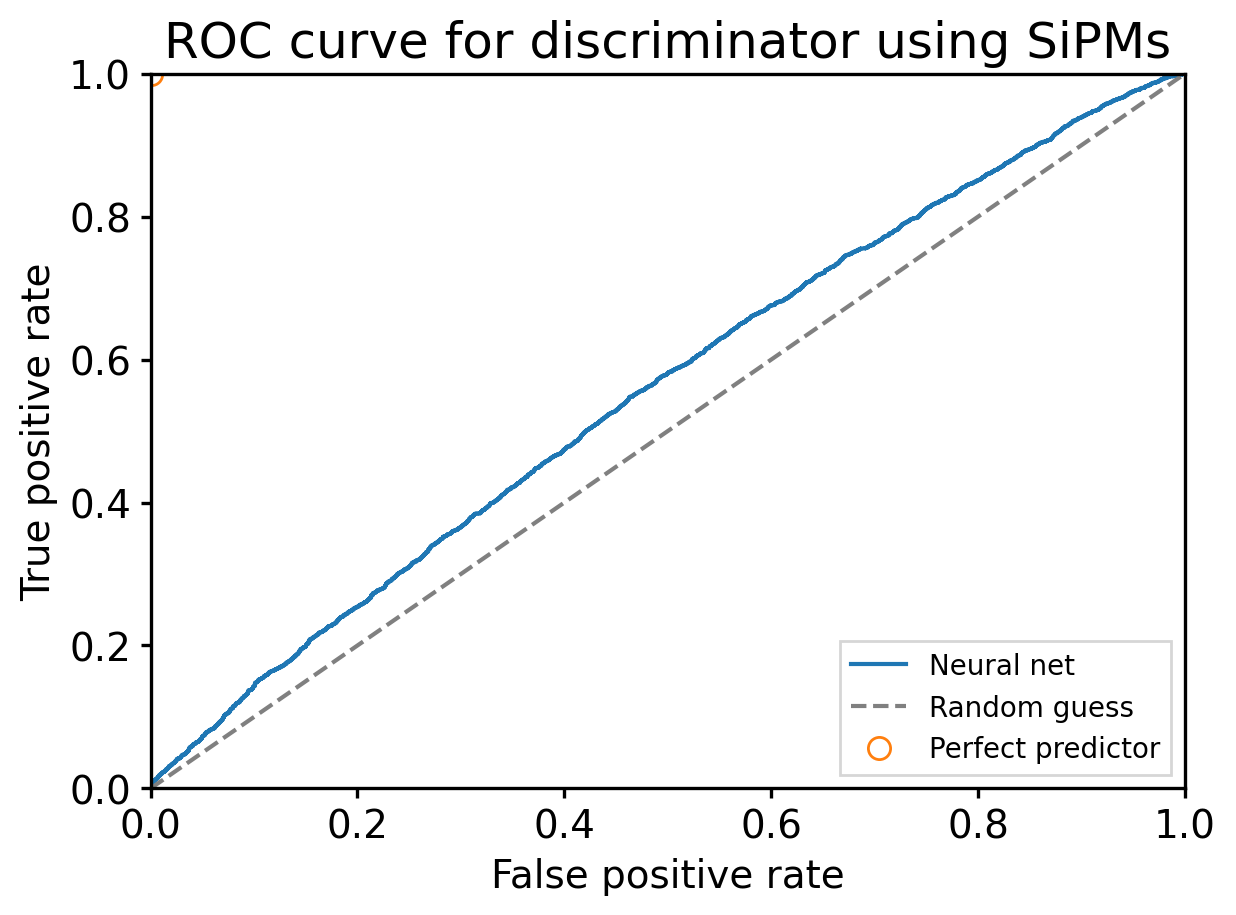

In [570]:
y_pred = np.array(np.array(model(X_val))[:,0])
y_true = np.copy(y_val)

sorted_indices = np.argsort(-y_pred)
y_true_sorted = y_true[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

P = np.sum(y_true)
N = len(y_true) - P

tpr = np.cumsum(y_true_sorted)/P
fpr = np.cumsum(1 - y_true_sorted)/N

youden = tpr - fpr - 1
opt_ind = np.argmax(youden)

print('Youden optimal cut keeps {:.1f}% of signal events and removes {:.1f}% of background events.'\
      .format(100*tpr[opt_ind], 100*(1. - fpr[opt_ind])))

fig, ax = plt.subplots()
ax.plot(fpr, tpr, label='Neural net')
ax.plot([0, 1], [0, 1], ls='--', color='grey', label='Random guess')
ax.plot([0], [1], marker='o', fillstyle='none', ls='none', ms=8, label='Perfect predictor')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve for discriminator using ' + sensors)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
if save_figures:
    fig.savefig('/home/clarke/figures/roc_individual' + sensors + '_' + fig_string + '.png')

titles = ['one', 'ten', 'hundred']
qes = np.array([1e-2, 1e-1, 1e0])
if save_figures:
    try:
        title_ind = np.argwhere(qes==pmt_qe)[0][0]
        np.save('qe_' + titles[title_ind] + '_' + sensors + '.npy', np.vstack((fpr, tpr)))
    except:
        if pmt_qe==0.3:
            np.save('qe_30_' + sensors + '.npy', np.vstack((fpr, tpr)))

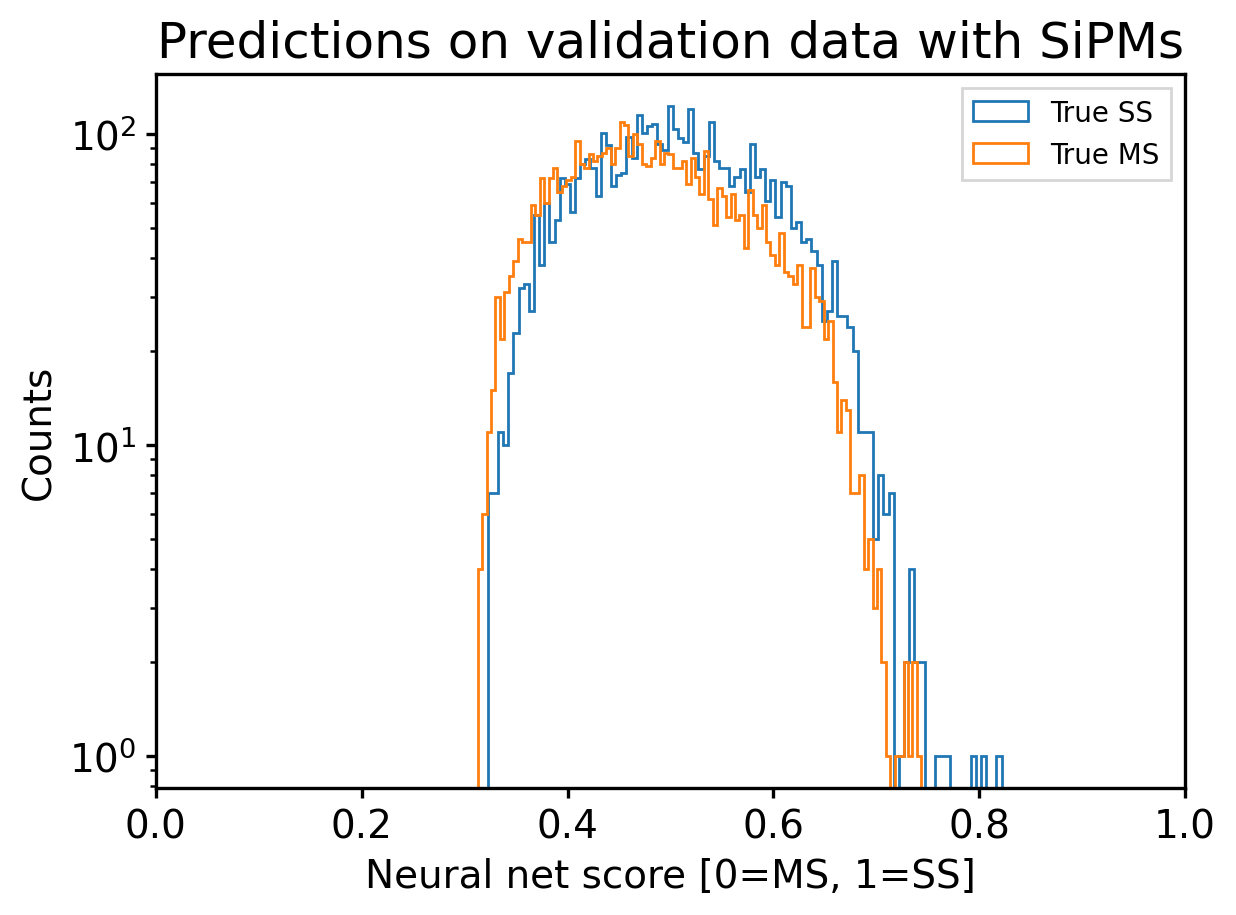

In [565]:
n_bins = 100

fig, ax = plt.subplots()
ax.hist(np.array(model(X_val)[y_val>0.5])[:,0], histtype='step', bins=n_bins, label='True SS')
ax.hist(np.array(model(X_val)[y_val<=0.5])[:,0], histtype='step', bins=n_bins, label='True MS')
ax.set_yscale('log')
ax.set_xlabel('Neural net score [0=MS, 1=SS]')
ax.set_ylabel('Counts')
ax.set_title('Predictions on validation data with ' + sensors)
ax.set_xlim([0, 1])
ax.legend()
if save_figures:
    fig.savefig('/home/clarke/figures/pdfs_individual' + sensors + '_' + fig_string + '.png')

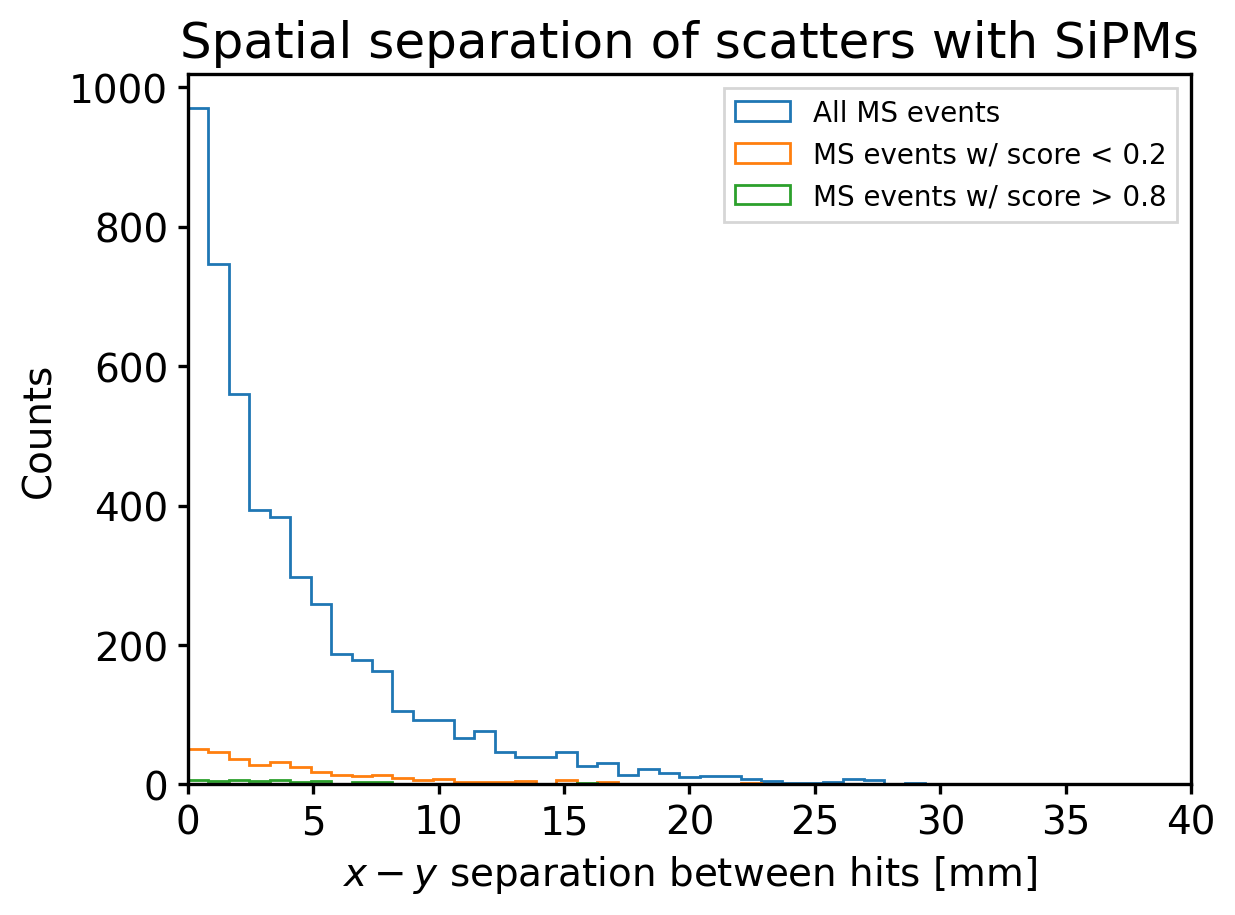

In [447]:
bins = np.linspace(0, 40, 50)

fig, ax = plt.subplots()
ax.hist(seps_val[y_val<0.5], histtype='step', label='All MS events', 
        density=False, bins=bins)
ax.hist(seps_val[(y_val<0.5) & (y_pred<0.2)], histtype='step', label='MS events w/ score < 0.2', \
        density=False, bins=bins)
ax.hist(seps_val[(y_val<0.5) & (y_pred>0.8)], histtype='step', label='MS events w/ score > 0.8', \
        density=False, bins=bins)
ax.set_xlabel('$x-y$ separation between hits [mm]')
ax.set_ylabel('Counts')
ax.set_title('Spatial separation of scatters with ' + sensors)
ax.set_xlim([0, 40])
ax.legend()
if save_figures:
    fig.savefig('/home/clarke/figures/by_separation_' + sensors + '_' + fig_string + '.png')

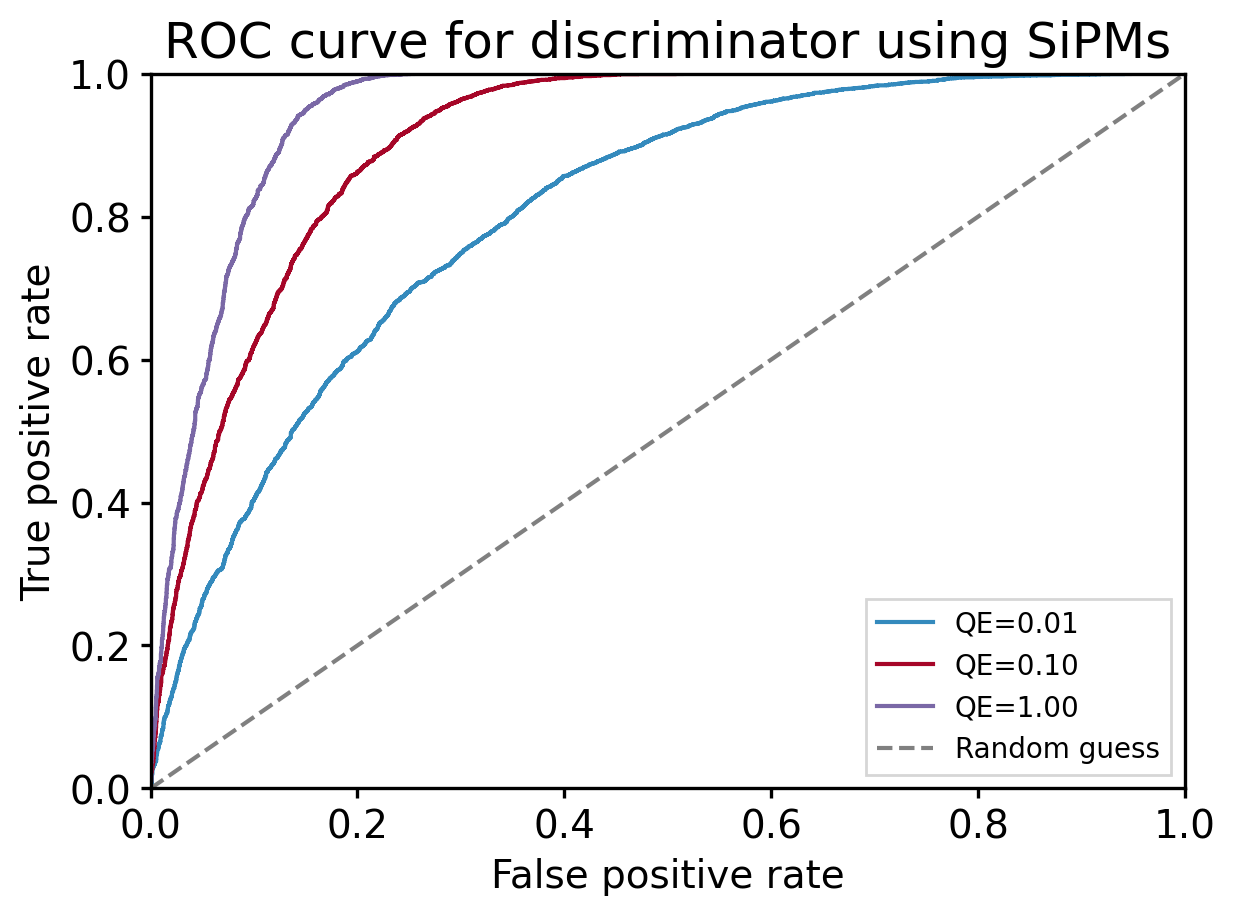

In [130]:
fig, ax = plt.subplots()
for i,title in enumerate(titles):
    fpr, tpr = np.load('qe_' + title + '_' + sensors + '.npy')
    ax.plot(fpr, tpr, label='QE={:.2f}'.format(qes[i]))
ax.plot([0, 1], [0, 1], ls='--', color='grey', label='Random guess')
#ax.plot([0], [1], marker='o', ls='none', ms=8, label='Perfect predictor')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve for discriminator using ' + sensors)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
if save_figures:
    fig.savefig('/home/clarke/figures/roc_comparison_' + sensors + '.png')

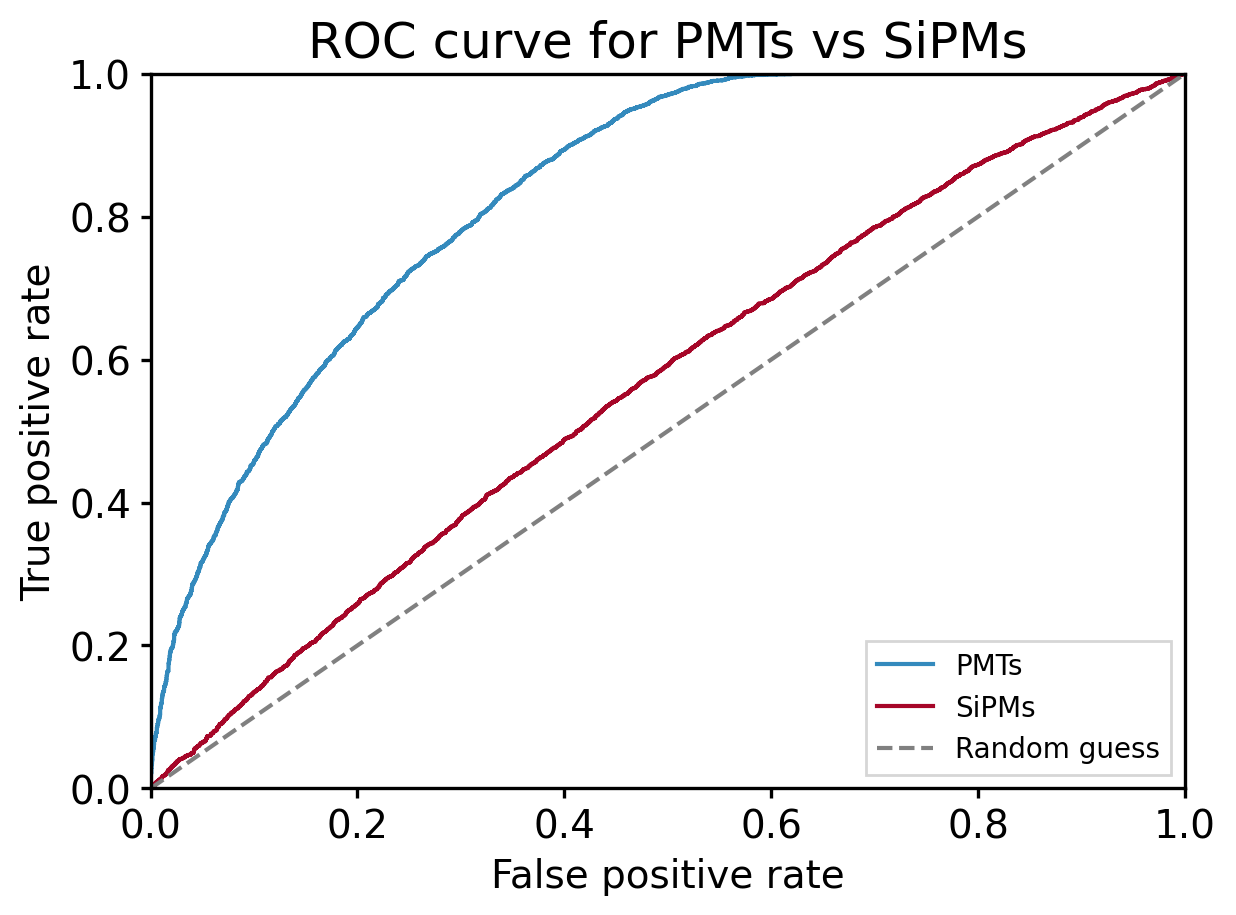

In [131]:
fig, ax = plt.subplots()
sensor_types = ['PMTs', 'SiPMs']
for i,title in enumerate(sensor_types):
    fpr, tpr = np.load('qe_30_' + sensor_types[i] + '.npy')
    ax.plot(fpr, tpr, label=sensor_types[i])
ax.plot([0, 1], [0, 1], ls='--', color='grey', label='Random guess')
#ax.plot([0], [1], marker='o', ls='none', ms=8, label='Perfect predictor')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.set_title('ROC curve for PMTs vs SiPMs')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.legend(loc='lower right')
if save_figures:
    fig.savefig('/home/clarke/figures/roc_comparison_sensors.png')

Text(0.5, 1.0, 'Average Pattern: Single-site')

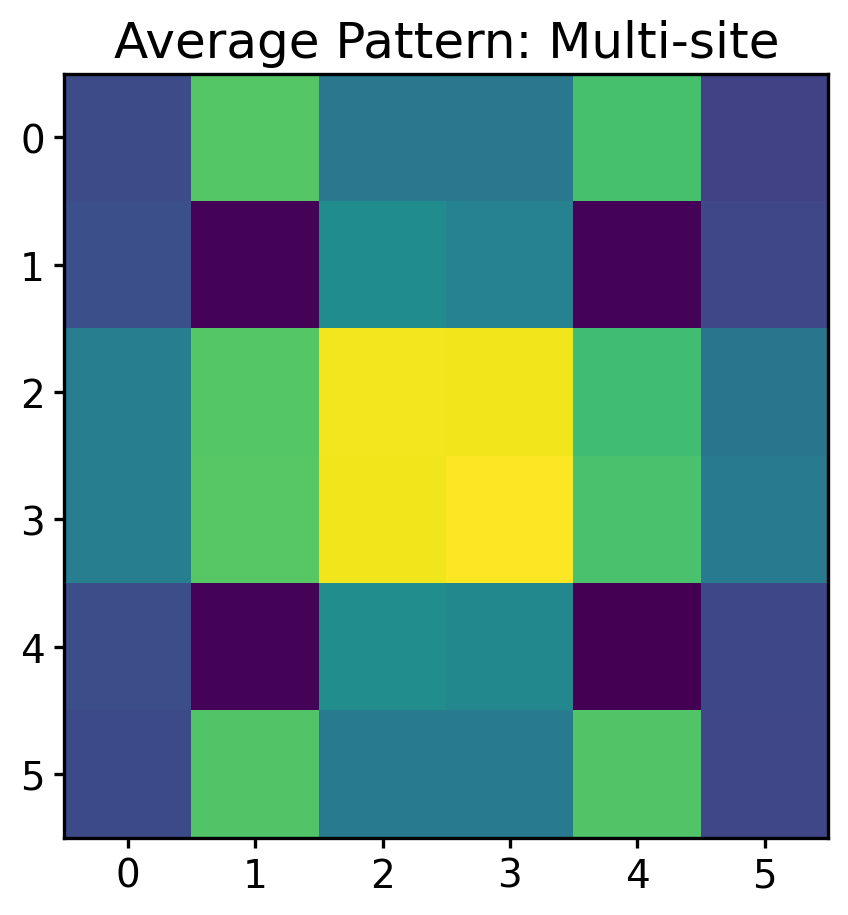

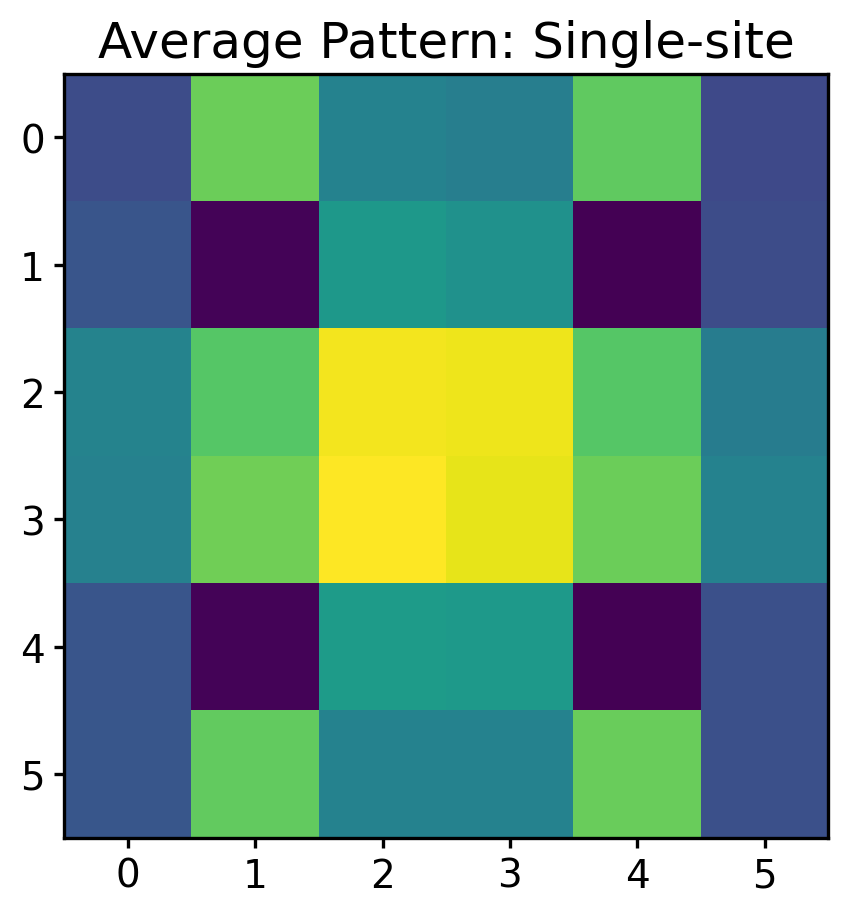

In [377]:
plt.figure()
plt.imshow(np.mean(X_train[y_train == 0], axis=0).squeeze(), cmap='viridis')
plt.title("Average Pattern: Multi-site")

plt.figure()
plt.imshow(np.mean(X_train[y_train == 1], axis=0).squeeze(), cmap='viridis')
plt.title("Average Pattern: Single-site")